In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 

In [2]:
df=sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
df.shape

(150, 5)

In [4]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df["species"]=le.fit_transform(df["species"])

In [5]:
df = df[df['species'] != 0][['sepal_width','petal_length','species']]

In [6]:
X=df.iloc[: , :-1]
y=df.iloc[:,-1]

In [7]:
from sklearn.tree import DecisionTreeClassifier 
from sklearn.linear_model import LogisticRegression 
from sklearn.svm import SVC 

In [8]:
dt=DecisionTreeClassifier()
lr=LogisticRegression()
svc=SVC()

In [9]:
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [10]:
df_train.head(3)

,sepal_width,petal_length,species
101,2.7,5.1,2
144,3.3,5.7,2
74,2.9,4.3,1


1.0


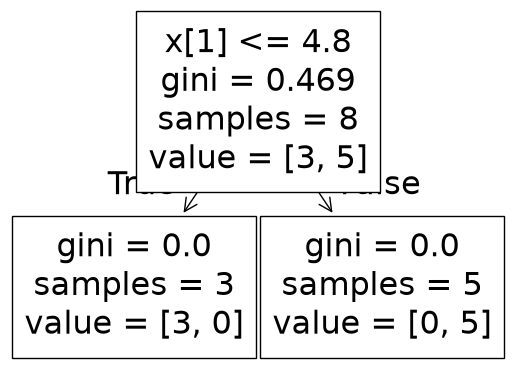

In [11]:
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score

df_bag = df_train.sample(8,replace=True)
X_train=df_bag.iloc[:,:-1]
y_train=df_bag.iloc[:,-1]

X_test=df_test.iloc[:,:-1]
y_test=df_test.iloc[:,-1]

def Evaluate(model , X_train , y_train , X_test , y_test):
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    print(accuracy_score(y_test , y_pred))
    plot_tree(model)

Evaluate(DecisionTreeClassifier() , X_train , y_train , X_test , y_test )

1.0


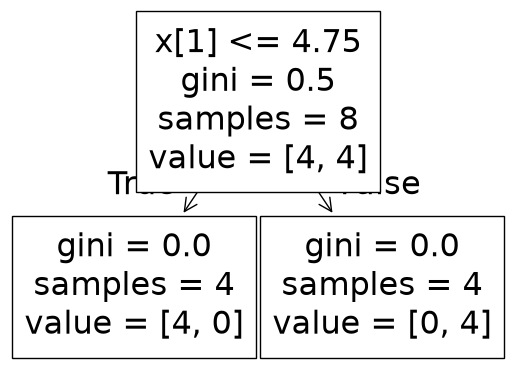

In [12]:
df_bag = df_train.sample(8)
X_train=df_bag.iloc[:,:-1]
y_train=df_bag.iloc[:,-1]

X_test=df_test.iloc[:,:-1]
y_test=df_test.iloc[:,-1]
Evaluate(DecisionTreeClassifier() , X_train , y_train , X_test , y_test)

### Bagging

In [13]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
X,y = make_classification(n_samples=10000, n_features=10,n_informative=3)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train,y_train)
y_pred = dt.predict(X_test)
print("Decision Tree accuracy",accuracy_score(y_test,y_pred))

Decision Tree accuracy 0.92


In [14]:
from sklearn.ensemble import BaggingClassifier 
bagging= BaggingClassifier(estimator=DecisionTreeClassifier() ,n_estimators=50 ,max_samples=0.25, max_features=1.0, bootstrap=True, bootstrap_features=False)

In [15]:
bagging.fit(X_train , y_train)
y_pred=bagging.predict(X_test)
print("Bagging accuracy",accuracy_score(y_test,y_pred))

Bagging accuracy 0.94


In [16]:
print(bagging.bootstrap_features , bagging.max_samples)

False 0.25


### Pasting -- Sample without replacement(Bootstrap=False)

In [17]:
bagging= BaggingClassifier(estimator=DecisionTreeClassifier() ,n_estimators=50 ,max_samples=0.25, max_features=1.0, bootstrap=False, bootstrap_features=False)
bagging.fit(X_train , y_train)
y_pred=bagging.predict(X_test)
print("Bagging accuracy",accuracy_score(y_test,y_pred))

Bagging accuracy 0.9405


### Random subPatches ( means only columns sampling

In [18]:
bagging= BaggingClassifier(estimator=DecisionTreeClassifier() ,n_estimators=50 ,max_samples=1.0, max_features=0.5, bootstrap=False, bootstrap_features=True)
bagging.fit(X_train , y_train)
y_pred=bagging.predict(X_test)
print("Bagging accuracy",accuracy_score(y_test,y_pred))

Bagging accuracy 0.9335


### Random Patches ( means both colmns and rows sampling)

In [19]:
bagging= BaggingClassifier(estimator=DecisionTreeClassifier() ,n_estimators=50 ,max_samples=0.25, max_features=0.5, bootstrap=True, bootstrap_features=False)
bagging.fit(X_train , y_train)
y_pred=bagging.predict(X_test)
print("Bagging accuracy",accuracy_score(y_test,y_pred))

Bagging accuracy 0.935


### OOB Score (use Out of Bag Score)

In [20]:
bagging= BaggingClassifier(estimator=DecisionTreeClassifier() ,n_estimators=50 ,max_samples=0.25, max_features=0.5, bootstrap=True, bootstrap_features=False , oob_score=True)
bagging.fit(X_train , y_train)
y_pred=bagging.predict(X_test)
print("Bagging accuracy",accuracy_score(y_test,y_pred))

Bagging accuracy 0.924


#### Hyperparameter tunning

In [21]:
from sklearn.model_selection import GridSearchCV  
parameters = {
    'n_estimators': [50,100,500], 
    'max_samples': [0.1,0.4,0.7,1.0],
    'bootstrap' : [True,False],
    'max_features' : [0.1,0.4,0.7,1.0]
    }

In [22]:
search = GridSearchCV(BaggingClassifier(), parameters, cv=5)

In [23]:
search.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",BaggingClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'bootstrap': [True, False], 'max_features': [0.1, 0.4, ...], 'max_samples': [0.1, 0.4, ...], 'n_estimators': [50, 100, ...]}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbo

In [25]:
print(search.best_params_)
search.best_score_

{'bootstrap': True, 'max_features': 0.7, 'max_samples': 1.0, 'n_estimators': 500}


np.float64(0.9460000000000001)

### Bagging Regressor

In [33]:
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score

X, y = datasets.load_diabetes(return_X_y=True)

In [28]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

In [29]:
dt = DecisionTreeRegressor()
dt.fit(X_train , y_train)
y_pred=dt.predict(X_test)
r2_score(y_test , y_pred)

0.09804459063456561

In [30]:
from sklearn.ensemble import BaggingRegressor 
bag= BaggingRegressor(estimator=None , n_estimators=10)

In [32]:
bag.fit(X_train , y_train)
y_pred=dt.predict(X_test)
r2_score(y_test , y_pred)

0.09804459063456561

In [ ]:
### HyperParameter --Take to much timey
# params = {'base_estimator': [None, LinearRegression(), KNeighborsRegressor()],
#           'n_estimators': [20,50,100],
#           'max_samples': [0.5,1.0],
#           'max_features': [0.5,1.0],
#           'bootstrap': [True, False],
#           'bootstrap_features': [True, False]}

# bagging_regressor_grid = GridSearchCV(BaggingRegressor(random_state=1, n_jobs=-1), param_grid =params, cv=3, n_jobs=-1, verbose=1)
# bagging_regressor_grid.fit(X_train, Y_train)

# print('Train R^2 Score : %.3f'%bagging_regressor_grid.best_estimator_.score(X_train, Y_train))
# print('Test R^2 Score : %.3f'%bagging_regressor_grid.best_estimator_.score(X_test, Y_test))
# print('Best R^2 Score Through Grid Search : %.3f'%bagging_regressor_grid.best_score_)
# print('Best Parameters : ',bagging_regressor_grid.best_params_)